# **Projet 2 : Autoencodeur Variationnel (VAE)**

## Introduction
Dans cette seconde partie, nous construisons un VAE sur le dataset Fashion-MNIST. Contrairement au GAN qui apprend à générer par compétition, le VAE apprend une représentation compressée (espace latent) des données probabiliste.

Nous utiliserons la Keras Functional API pour définir une architecture convolutionnelle, plus adaptée aux images que des couches denses simples.

## 1. Initialisation et Paramètres
Configuration de l'environnement et définition des hyperparamètres.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Montage Drive (pour la sauvegarde)
import os
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Dossier de sauvegarde
PROJECT_DIR = '/content/drive/MyDrive/project_/run_vae'
os.makedirs(PROJECT_DIR, exist_ok=True)

In [39]:
# Hyperparamètres
LATENT_DIM = 2       # Dimension de l'espace latent (2D permet la visualisation)
EPOCHS     = 35     # Suffisant pour converger
BATCH_SIZE = 128
IMG_SHAPE  = (28, 28, 1)

print(f"Configuration : Latent Dim={LATENT_DIM}, Epochs={EPOCHS}")

Configuration : Latent Dim=2, Epochs=35


## 2. Chargement et Préparation des Données
Nous utilisons Fashion-MNIST, un dataset de 60 000 images d'articles de mode (T-shirts, pantalons, etc.).

Traitements effectués :

1. Normalisation : Conversion des pixels [0, 255] vers [0, 1]. C'est crucial car la dernière couche du décodeur utilisera une activation Sigmoid.

2. Reshape : Ajout de la dimension du canal (28, 28, 1) pour les convolutions.

Dataset chargé : (70000, 28, 28, 1)


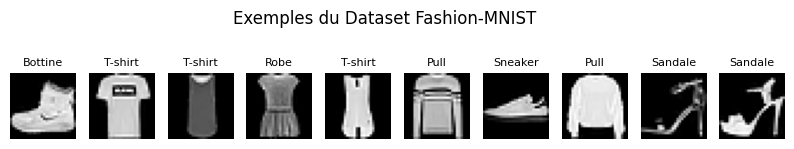

In [40]:
# Chargement direct depuis Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalisation [0, 1] et Reshape
fashion_data = np.concatenate([x_train, x_test], axis=0)
fashion_data = np.expand_dims(fashion_data, -1).astype("float32") / 255.0

print(f"Dataset chargé : {fashion_data.shape}")

# Visualisation
plt.figure(figsize=(10, 2))
class_names = ["T-shirt", "Pantalon", "Pull", "Robe", "Manteau",
               "Sandale", "Chemise", "Sneaker", "Sac", "Bottine"]
for i in range(10):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(fashion_data[i].squeeze(), cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=8)
    plt.axis("off")
plt.suptitle("Exemples du Dataset Fashion-MNIST")
plt.show()

## 3. Conception de l'Architecture (Encoder & Decoder)
Justification des choix architecturaux :
- Convolutions (Conv2D) : Nous préférons les CNN aux couches denses (Dense) car ils capturent mieux les relations spatiales des pixels et réduisent le nombre de paramètres.

- Sampling Layer (L'astuce de reparamétrisation) : Le VAE n'encode pas une image vers un point fixe $z$, mais vers une distribution normale ($\mu, \sigma$). Cette couche permet de rendre le processus dérivable pour la backpropagation.

In [41]:
# --- 3.1 Couche de Sampling (Reparameterization Trick) ---
class Sampling(layers.Layer):
    """Utilise (z_mean, z_log_var) pour échantillonner z, le vecteur encodant."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# --- 3.2 L'Encodeur ---
def build_encoder(latent_dim):
    encoder_inputs = keras.Input(shape=IMG_SHAPE)

    # Bloc 1
    x = layers.Conv2D(32, 3, strides=2, padding="same")(encoder_inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Bloc 2
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Aplatissement
    x = layers.Flatten()(x)
    x = layers.Dense(32, activation="relu")(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])

    return keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# --- 3.3 Le Décodeur ---
def build_decoder(latent_dim):
    latent_inputs = keras.Input(shape=(latent_dim,))

    # Projection et Reshape
    x = layers.Dense(7 * 7 * 64)(latent_inputs)
    x = layers.LeakyReLU()(x)
    x = layers.Reshape((7, 7, 64))(x)

    # Bloc 1 (Upsampling)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Bloc 2 (Upsampling)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Sortie
    decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)

    return keras.Model(latent_inputs, decoder_outputs, name="decoder")

## 4. Construction du Modèle VAE et Fonction de Coût
Justification de la Fonction de Coût (Loss) : La perte totale du VAE est la somme de deux termes :

1. Reconstruction Loss : Mesure à quel point l'image sortie ressemble à l'entrée. Nous utilisons la binary_crossentropy car nos pixels sont normalisés entre [0,1], ce qui est plus efficace que l'erreur quadratique (MSE) pour converger sur des images monochromes.

2. KL Divergence (Kullback-Leibler) : Force la distribution latente à ressembler à une loi normale standard. Cela assure que l'espace latent est continu et permet la génération fluide.

In [42]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta  # Facteur de pondération KL (Beta-VAE)
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # Forward pass
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # 1. Perte de Reconstruction (Binary Crossentropy)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )

            # 2. Perte KL (Régularisation de l'espace latent)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            # 3. Perte Totale
            total_loss = reconstruction_loss + (self.beta * kl_loss)

        # Backpropagation
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Mise à jour des logs
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

## 5. Entraînement
Nous utilisons l'optimiseur Adam, standard pour ce type de tâche.

In [43]:
encoder = build_encoder(LATENT_DIM)
decoder = build_decoder(LATENT_DIM)

print("Architecture Encodeur :")
encoder.summary()
print("\nArchitecture Décodeur :")
decoder.summary()

Architecture Encodeur :


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_11[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_21      │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ leaky_re_lu_21[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 64)  │        256 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_22      │ (None, 7, 7, 64)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 3136)      │          0 │ leaky_re_lu_22[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │    100,384 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         66 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         66 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_5          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 119,716 (467.64 KB)

 Trainable params: 119,524 (466.89 KB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_23 (LeakyReLU)      │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_24 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,473 (255.75 KB)

 Trainable params: 65,281 (255.00 KB)

 Non-trainable params: 192 (768.00 B)

In [44]:
# Compilation
vae = VAE(encoder, decoder, beta=1.0)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001))

# Entraînement
print("Démarrage de l'entraînement du VAE...")
history = vae.fit(fashion_data, epochs=EPOCHS, batch_size=BATCH_SIZE)

# Sauvegarde des sous-modèles
encoder.save(os.path.join(PROJECT_DIR, 'vae_encoder.h5'))
decoder.save(os.path.join(PROJECT_DIR, 'vae_decoder.h5'))
print("Modèles sauvegardés.")

Démarrage de l'entraînement du VAE...
Epoch 1/35
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - kl_loss: 5.7121 - loss: 351.9972 - reconstruction_loss: 346.2852
Epoch 2/35
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 5.8002 - loss: 275.1524 - reconstruction_loss: 269.3522
Epoch 3/35
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 5.8809 - loss: 271.7562 - reconstruction_loss: 265.8753
Epoch 4/35
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 5.9424 - loss: 269.7116 - reconstruction_loss: 263.7692
Epoch 5/35
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 5.9991 - loss: 268.7062 - reconstruction_loss: 262.7071
Epoch 6/35
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 6.0309 - loss: 267.7483 - reconstruction_loss: 261.7173
Epoch 7/35
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 6.0522 - loss: 267.3081 - reconstruction_loss: 261.2559
Epoch 8/35
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 6.0627 - loss: 266.9415 - reconstruction_loss: 260.8788
Epoch 9/

Modèles sauvegardés.


## 6. Analyse de l'Espace Latent et Génération
Puisque nous avons choisi LATENT_DIM = 2, nous pouvons visualiser l'organisation de l'espace latent. Les vêtements similaires devraient se regrouper naturellement.

### 6.1 Qualité de Reconstruction (Réel vs Reconstruit)
on vérifie si le VAE arrive à reproduire l'entrée.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


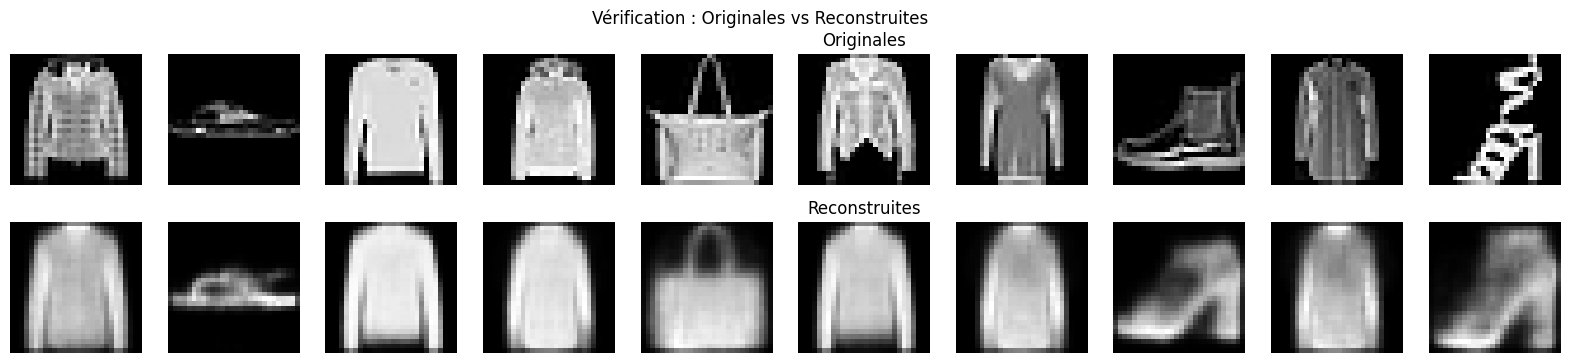

In [51]:
def check_results(model, data, n=10):
    # 1. Reconstruction
    indices = np.random.randint(0, len(data), n)
    test_images = data[indices]
    z_mean, _, _ = model.encoder.predict(test_images)
    reconstructed_images = model.decoder.predict(z_mean)

    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Orig
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(test_images[i].squeeze(), cmap='gray')
        plt.axis("off")
        if i == n//2: plt.title("Originales")
        # Reco
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed_images[i].squeeze(), cmap='gray')
        plt.axis("off")
        if i == n//2: plt.title("Reconstruites")
    plt.suptitle("Vérification : Originales vs Reconstruites")
    plt.show()

x_test_normalized = np.expand_dims(x_test, -1).astype("float32") / 255.0
check_results(vae, x_test_normalized)

### 6.2 Espace Latent et Génération (Le Manifold)
Visualise la carte des vêtements et la génération de nouveaux designs.

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


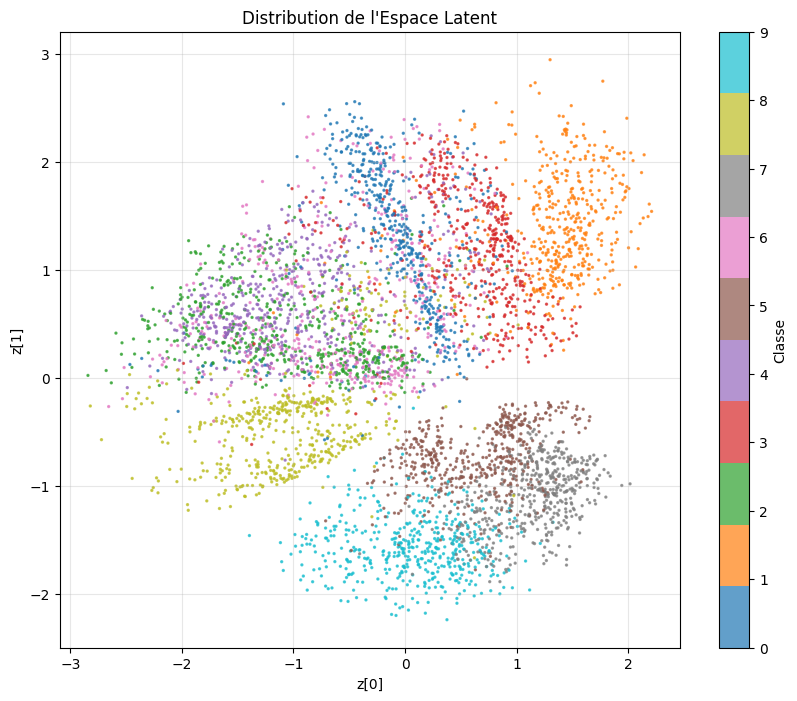

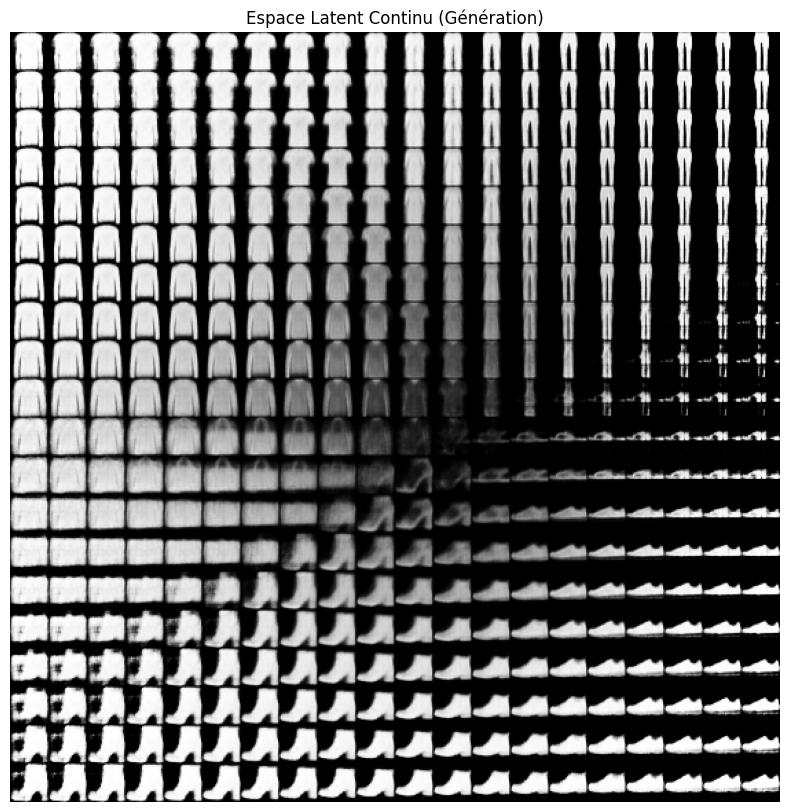

In [52]:
def plot_latent_analysis(encoder, decoder, data, labels):
    # --- 1. Carte de l'espace latent ---
    z_mean, _, _ = encoder.predict(data)
    plt.figure(figsize=(10, 8))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels, cmap='tab10', s=2, alpha=0.7)
    plt.colorbar(label="Classe")
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title("Distribution de l'Espace Latent")
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- 2. Génération par grille (Morphing) ---
    n = 20  # Grille 20x20
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))

    # On scanne de -3 à +3 (Loi normale)
    grid_x = np.linspace(-3, 3, n)
    grid_y = np.linspace(-3, 3, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size,
                   j * digit_size : (j + 1) * digit_size] = digit

    plt.figure(figsize=(10, 10))
    plt.imshow(figure, cmap='gray')
    plt.title("Espace Latent Continu (Génération)")
    plt.axis("off")
    plt.show()

# Analyse sur 5000 images de test
plot_latent_analysis(encoder, decoder, x_test_normalized[:5000], y_test[:5000])